### Sequential workflow - Temperature Conversion 

In [1]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict

In [2]:
# Define the state
class TemperatureState(TypedDict):
    temp_celsius:float
    temp_fahrenheit: float

In [3]:
# convert_temp function

def convert_temp(state: TemperatureState)-> TemperatureState: 
    # This fctn takes input as TemperatureState and return output as TemperatureState
    celsius = state['temp_celsius']
    fahrenheit = (celsius*9/5) + 32

    # update the state memory
    state['temp_fahrenheit'] = round(fahrenheit,2)
    return state


In [4]:
# Define and compile the graph by creating the object of the Stategraph
graph = StateGraph(TemperatureState)

# add nodes to the graph. START and END are the dummy nodes so we dont need to create a serparate node for them.
graph.add_node('convert_temperature', convert_temp)

# add edges to the graph.
graph.add_edge(START,'convert_temperature')
graph.add_edge('convert_temperature',END)

# compile the graph
workflow = graph.compile()

In [5]:
#Execute the graph
initial_state = {'temp_celsius': 28.5}
final_state = workflow.invoke(initial_state)

In [6]:
final_state

{'temp_celsius': 28.5, 'temp_fahrenheit': 83.3}

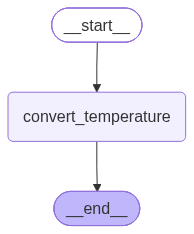

In [7]:
# Visulise this graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### Adding Labels
- If fahrenheit temp is less then 50 then cold
- If less than 77 then mild
- else hot
- so for this a new node is created
- and a weather_status(state) to save these data

In [8]:
# Define the state
class TemperatureState(TypedDict):
    temp_celsius:float
    temp_fahrenheit: float
    weather_status: str

In [9]:
def label_weather(state: TemperatureState)->TemperatureState:
    fahrenheit = state['temp_fahrenheit']

    if fahrenheit < 50:
        state["weather_status"] = "cold"

    elif 50 <= fahrenheit < 80:
            state["weather_status"] = "cold"

    else :
            state["weather_status"] = "hot"

    return state

In [10]:
# Define and compile the graph by creating the object of the Stategraph
graph = StateGraph(TemperatureState)

# add nodes to the graph. START and END are the dummy nodes so we dont need to create a serparate node for them.
graph.add_node('convert_temperature', convert_temp)
graph.add_node('lable_weather', label_weather)

# add edges to the graph.
graph.add_edge(START,'convert_temperature')
graph.add_edge('convert_temperature','lable_weather')
graph.add_edge('lable_weather',END)

# compile the graph
workflow = graph.compile()

In [11]:
#Execute the graph
initial_state = {'temp_celsius': 18.5}
final_state = workflow.invoke(initial_state)

In [12]:
final_state

{'temp_celsius': 18.5, 'temp_fahrenheit': 65.3, 'weather_status': 'cold'}

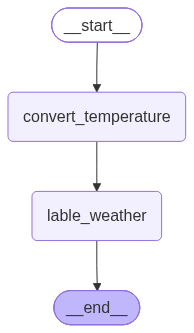

In [13]:
# Visulise this graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### Creating workflow using LLM

In [14]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

True

In [15]:
# Define the LLM
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [16]:
# create the state
class LLMState(TypedDict):
    question:str
    answer:str


In [17]:
# Creating the nodes
def llm_qa(state:LLMState)->LLMState:
    # extract the question from state
    question = state['question']

    prompt = f'Answer the following question{question}'

    # ask question to llm
    answer = llm.invoke(prompt).content

    # update the ans in state
    state['answer'] = answer

    return state

In [18]:
# creating and defining the graph
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile( )


In [19]:
# execute the graph
initial_state = {'question': "Who is the PM of India"}
final_state = workflow.invoke(initial_state)

In [20]:
final_state

{'question': 'Who is the PM of India',
 'answer': 'As of the most recent information available to me (up to\u202fJune\u202f2024), **Narendra\u202fModi** is the Prime Minister of India.\u202fHe has held the office since May\u202f2014 and was re‑elected in the 2019 general election.\n\nPlease keep in mind that political leadership can change after elections, resignations, or other events, so it’s a good idea to verify whether there have been any updates since then if you need the absolutely current holder of the office.'}

In [21]:
final_state['answer']

'As of the most recent information available to me (up to\u202fJune\u202f2024), **Narendra\u202fModi** is the Prime Minister of India.\u202fHe has held the office since May\u202f2014 and was re‑elected in the 2019 general election.\n\nPlease keep in mind that political leadership can change after elections, resignations, or other events, so it’s a good idea to verify whether there have been any updates since then if you need the absolutely current holder of the office.'

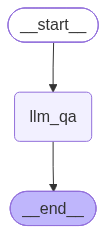

In [22]:
# Visulise this graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### Prompt Chaining 
- Initially we are using one LLM. 
- So prompt chaining means we can use multiple LLMs.

In [24]:
# Defining the State
class BlogState(TypedDict):
    title:str
    outline:str
    content: str

In [35]:
# creating nodes
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = llm.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [36]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the following outline - {outline}'

    content = llm.invoke(prompt).content

    state['content'] = content

    return state

In [37]:
# defining and compiling the graph
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [38]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '**Blog Title:** *The Rise of AI in India: How the Sub‑Continent Is Shaping the Future of Artificial Intelligence*  \n\n**Target Length:** 2,500\u202f–\u202f3,000\u202fwords (≈\u202f10\u202f–\u202f12 sections)  \n**Primary Keywords:** AI in India, Indian AI market, AI startups India, government AI policy India, AI adoption India  \n**Secondary Keywords:** AI research India, AI education, AI ethics India, AI in healthcare India, AI in agriculture, AI talent pipeline  \n\n---\n\n## 1. Introduction – Setting the Stage  \n- **Hook:** A striking statistic (e.g., “India’s AI market is projected to reach **$17\u202fbillion by 2027**, outpacing many developed economies”).  \n- **Why it matters:** Global AI race, India’s demographic dividend, and the potential for socioeconomic transformation.  \n- **Thesis statement:** Overview of the forces driving AI’s rapid ascent in India and what this means for businesses, policymakers, and citizens.  \n\n---\n\

In [43]:
print(final_state['outline'])

**Blog Title:** *The Rise of AI in India: How the Sub‑Continent Is Shaping the Future of Artificial Intelligence*  

**Target Length:** 2,500 – 3,000 words (≈ 10 – 12 sections)  
**Primary Keywords:** AI in India, Indian AI market, AI startups India, government AI policy India, AI adoption India  
**Secondary Keywords:** AI research India, AI education, AI ethics India, AI in healthcare India, AI in agriculture, AI talent pipeline  

---

## 1. Introduction – Setting the Stage  
- **Hook:** A striking statistic (e.g., “India’s AI market is projected to reach **$17 billion by 2027**, outpacing many developed economies”).  
- **Why it matters:** Global AI race, India’s demographic dividend, and the potential for socioeconomic transformation.  
- **Thesis statement:** Overview of the forces driving AI’s rapid ascent in India and what this means for businesses, policymakers, and citizens.  

---

## 2. A Brief Historical Timeline  
| Year | Milestone | Impact |
|------|-----------|--------

In [42]:
print(final_state['content'])

**The Rise of AI in India: How the Sub‑Continent Is Shaping the Future of Artificial Intelligence**  
*By *[Your Name]* – *[Date]*  

---  

### 1. Introduction – Setting the Stage  

> **“India’s AI market is projected to reach $17 billion by 2027, outpacing many developed economies.”**  

The numbers are impossible to ignore. In a world where artificial intelligence (AI) has become the engine of the next industrial revolution, India is emerging as a heavyweight contender. With a **demographic dividend of over 1 billion people**, a rapidly expanding digital infrastructure, and a policy ecosystem that is actively courting the technology, the sub‑continent is poised to rewrite the rules of AI innovation.

Why does this matter?  

* **Global AI race:** Nations from the United States to China are pouring billions into AI research, talent development, and commercialization. India’s growing AI market means it can compete for high‑value contracts, attract top‑tier talent, and influence globa

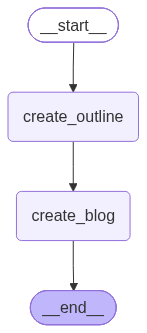

In [44]:
# Visulise this graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())